# PneumoniaMNIST: basic exploratory data analysis

This notebook inspects the already-downloaded dataset. It is descriptive only: the dataset and model are educational and are not suitable for clinical decisions.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from medmnist import PneumoniaMNIST

DATA_DIR = Path("../data")
if not (DATA_DIR / "pneumoniamnist.npz").exists():
    # we automatically run teh training script if the dataset is missing
    
    raise FileNotFoundError("Run `make train` first so data/pneumoniamnist.npz exists.")

LABEL_NAMES = {0: "normal", 1: "pneumonia"}

FileNotFoundError: Run `make train` first so data/pneumoniamnist.npz exists.

## Load all predefined splits

MedMNIST provides train, validation, and test splits. We inspect them separately rather than combining them, because the test split must remain untouched during model development.

In [3]:
datasets = {
    split: PneumoniaMNIST(split=split, root=str(DATA_DIR), download=False)
    for split in ("train", "val", "test")
}

for split, dataset in datasets.items():
    images = np.asarray(dataset.imgs)
    labels = np.asarray(dataset.labels).reshape(-1)
    print(f"{split:>5}: {len(dataset):>5} images, shape={images.shape}, labels={np.unique(labels).tolist()}")

train:  4708 images, shape=(4708, 28, 28), labels=[0, 1]
  val:   524 images, shape=(524, 28, 28), labels=[0, 1]
 test:   624 images, shape=(624, 28, 28), labels=[0, 1]


In [4]:
def split_arrays(split):
    dataset = datasets[split]
    return np.asarray(dataset.imgs), np.asarray(dataset.labels).reshape(-1)

train_images, train_labels = split_arrays("train")
val_images, val_labels = split_arrays("val")
test_images, test_labels = split_arrays("test")

print("Total images:", len(train_images) + len(val_images) + len(test_images))

Total images: 5856


## Class balance

Class imbalance is one reason the training code uses a weighted loss. We should understand the label distribution before interpreting accuracy.

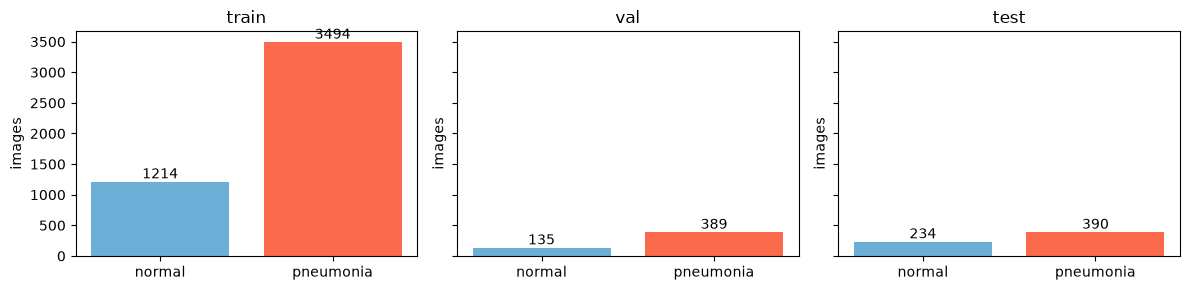

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for axis, (split, labels) in zip(axes, (("train", train_labels), ("val", val_labels), ("test", test_labels))):
    counts = np.bincount(labels.astype(int), minlength=2)
    axis.bar([LABEL_NAMES[0], LABEL_NAMES[1]], counts, color=["#6baed6", "#fb6a4a"])
    axis.set_title(split)
    axis.set_ylabel("images")
    for index, count in enumerate(counts):
        axis.text(index, count, str(count), ha="center", va="bottom")
plt.tight_layout()
plt.show()

## Representative images

These images are 28x28 grayscale thumbnails. Visual inspection helps us catch unexpected data issues before training.

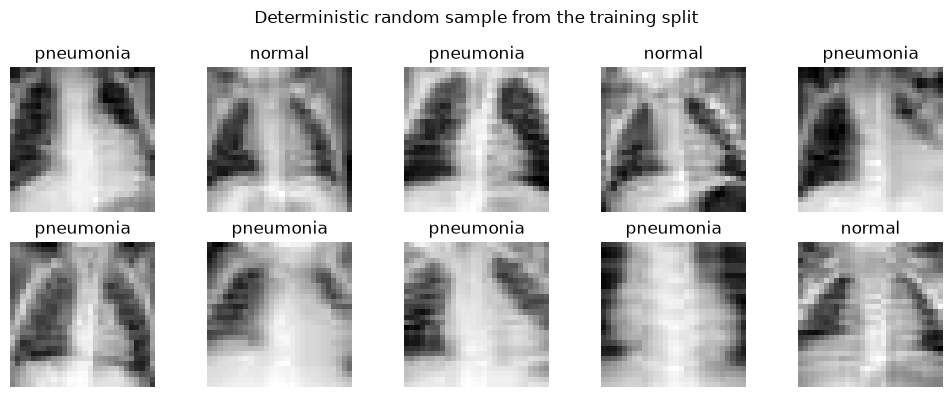

In [6]:
rng = np.random.default_rng(42)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for axis in axes.flat:
    index = int(rng.integers(len(train_images)))
    axis.imshow(train_images[index], cmap="gray")
    axis.set_title(LABEL_NAMES[int(train_labels[index])])
    axis.axis("off")
plt.suptitle("Deterministic random sample from the training split")
plt.tight_layout()
plt.show()

## Pixel-value distributions

The raw images contain integer pixel values from 0 to 255. Our preprocessing later scales them to 0 to 1 and then normalizes them to approximately -1 to 1.

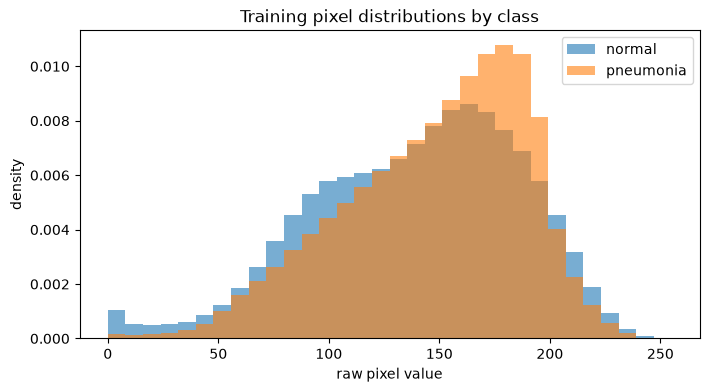

Normal mean/std: 139.9 46.82
Pneumonia mean/std: 147.9 41.29


In [7]:
normal_pixels = train_images[train_labels == 0].ravel()
pneumonia_pixels = train_images[train_labels == 1].ravel()

plt.figure(figsize=(8, 4))
plt.hist(normal_pixels, bins=32, alpha=0.6, density=True, label="normal")
plt.hist(pneumonia_pixels, bins=32, alpha=0.6, density=True, label="pneumonia")
plt.xlabel("raw pixel value")
plt.ylabel("density")
plt.title("Training pixel distributions by class")
plt.legend()
plt.show()

print("Normal mean/std:", round(float(normal_pixels.mean()), 2), round(float(normal_pixels.std()), 2))
print("Pneumonia mean/std:", round(float(pneumonia_pixels.mean()), 2), round(float(pneumonia_pixels.std()), 2))

## Initial observations

Before training, record: the split sizes, label balance, image dimensions, and whether any images or labels look malformed. These observations become part of the model-development record and help explain later choices such as class-weighted loss.